In [1536]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [1537]:
#df = pd.read_csv('database/test.csv')
df = pd.read_csv('database/train_mod.csv')
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45654403,1399,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005 km,...,12,13328.0,1,2021-03-14,Sim,FM,8,8497,Usado,Econômico
1,44731507,1018,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3,NaN,...,8,16621.0,5,2021-08-08,Sim,AM,4,6796,Usado,Econômico
2,45774419,-,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000 km,...,2,8467.0,1,2020-04-14,Sim,FM,5,3382,Usado,Econômico
3,45769185,862,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966 km,...,0,3607.0,1,2020-01-13,Não,AM/FM,7,1458,Usado,Econômico
4,45809263,446,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901 km,...,4,11726.0,2,2021-10-11,Não,AM,5,5374,Usado,Econômico


In [1538]:
df.columns.tolist()

['ID',
 'Débitos',
 'Fabricante',
 'Modelo',
 'Ano',
 'Categoria',
 'Couro',
 'Combustivel',
 'Volume_motor',
 'Km',
 'Cilindros',
 'Tipo_cambio',
 'Tração',
 'Portas',
 'Rodas',
 'Cor',
 'Airbags',
 'Preco',
 'Numero_proprietarios',
 'Data_ultima_lavagem',
 'Adesivos_personalizados',
 'Radio_AM_FM',
 'Historico_troca_oleo',
 'Codigo_concessionaria',
 'Classificacao_Veiculo',
 'Faixa_Preco']

### Coluna ID excluída pois são valores aleatórios

In [1539]:
#colunas_excluir = ["Data_ultima_lavagem", "ID", "Faixa_Preco", "Codigo_concessionaria", "Classificacao_Veiculo"]
colunas_excluir = ["ID"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Débitos

In [1540]:
df["Débitos"] = pd.to_numeric(
    df["Débitos"].replace("-", np.nan),
    errors="coerce"
)

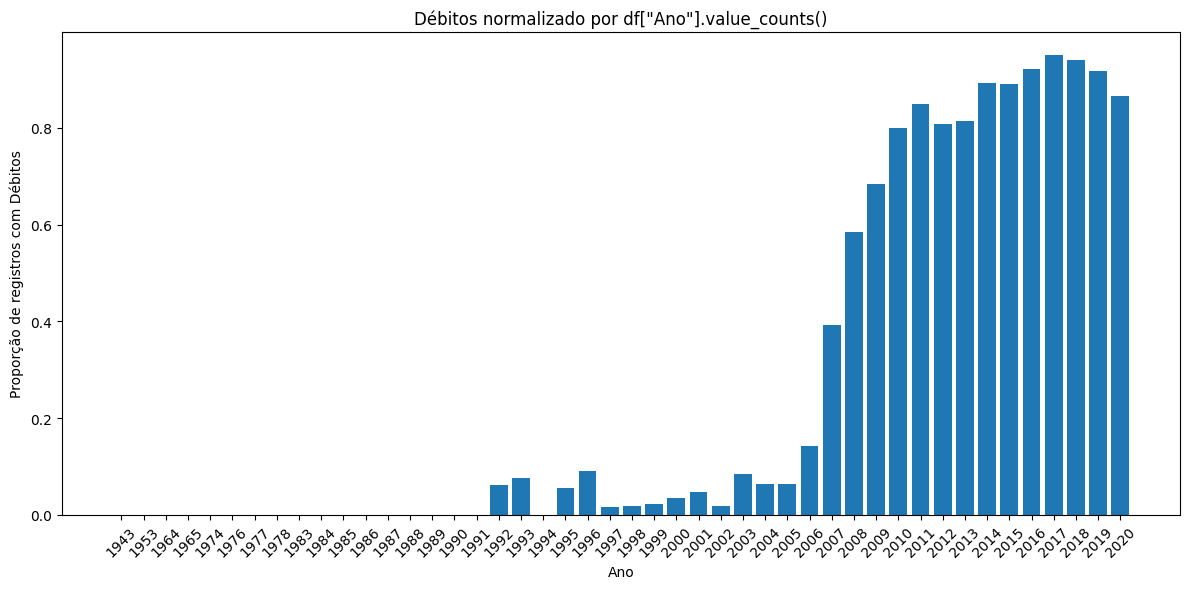

In [1541]:
df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

# Total de registros por ano
total_por_ano = df["Ano"].value_counts().sort_index()

# Quantidade de registros com Débitos válidos por ano
com_debito_por_ano = df.dropna(subset=["Ano", "Débitos"])["Ano"].value_counts().sort_index()

# Normalização pela contagem total de registros do ano
normalizado = (com_debito_por_ano / total_por_ano).fillna(0).sort_index()

graf = normalizado.reset_index()
graf.columns = ["Ano", "Proporcao_com_Debito"]

plt.figure(figsize=(12, 6))
plt.bar(graf["Ano"].astype(int).astype(str), graf["Proporcao_com_Debito"])
plt.xlabel("Ano")
plt.ylabel("Proporção de registros com Débitos")
plt.title('Débitos normalizado por df["Ano"].value_counts()')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1542]:
df['Débitos'] = df['Débitos'].fillna(0)
df['Débitos'].isna().sum()

0

### Coluna Fabricante

In [1543]:
df["Fabricante"].value_counts()

Fabricante
TOYOTA           1794
HYUNDAI          1496
MERCEDES-BENZ     939
FORD              507
BMW               483
HONDA             469
CHEVROLET         468
LEXUS             460
NISSAN            275
VOLKSWAGEN        250
SSANGYONG         215
OPEL              185
KIA               176
MITSUBISHI        136
SUBARU            127
AUDI              114
MAZDA              81
JEEP               61
DAEWOO             45
SUZUKI             44
DODGE              39
FIAT               39
PORSCHE            29
LAND ROVER         28
VAZ                27
MINI               22
RENAULT            21
JAGUAR             19
CHRYSLER           12
INFINITI           11
ACURA              10
SKODA               9
LINCOLN             9
CADILLAC            9
DAIHATSU            8
GMC                 8
GAZ                 7
VOLVO               7
BUICK               5
PEUGEOT             4
CITROEN             4
ISUZU               3
SCION               3
UAZ                 3
MOSKVICH            3

In [1544]:
df["Fabricante"].isna().sum()

0

### Coluna Modelo

In [1545]:
df["Modelo"].value_counts()

Modelo
Prius              507
Camry              474
Elantra            407
Santa FE           264
Sonata             251
                  ... 
E 350 w211           1
Sonata HYBRID        1
Prius V ALPINA       1
Sprinter 315CDI      1
240                  1
Name: count, Length: 1032, dtype: int64

In [1546]:
df["Modelo"].isna().sum()

0

### Coluna Ano

In [1547]:
df["Ano"].value_counts()

Ano
2012    994
2014    946
2013    943
2011    736
2010    713
2016    632
2015    608
2017    430
2008    322
2009    259
2018    234
2007    217
2004    172
2003    165
2002    158
2005    156
2006    147
2019    147
2000    119
1998    109
2001    105
1999     90
1997     61
1996     55
1995     54
1994     21
1992     16
2020     15
1993     13
1988      7
1991      7
1989      6
1990      5
1984      5
1983      3
1974      2
1953      2
1985      2
1986      2
1964      1
1977      1
1987      1
1943      1
1978      1
1965      1
1976      1
Name: count, dtype: int64

In [1548]:
df["Ano"].isna().sum()

0

### Coluna Categoria

In [1549]:
df["Categoria"].value_counts()

Categoria
Sedan             3826
SUV               2555
Hatchback         1314
Minivan            285
Cupê               261
Universal          156
Microonibus        127
Vagao de carga     115
Picape              23
Conversivel         17
Limousine            6
Name: count, dtype: int64

In [1550]:
df["Categoria"].isna().sum()

0

### Coluna Couro

In [1551]:
df["Couro"].value_counts()

Couro
Sim    6192
Nao    2493
Name: count, dtype: int64

In [1552]:
df["Couro"].isna().sum()

0

### Coluna Combustivel

In [1553]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       1966
Hibrido        1710
GASOLINA       1184
Gasol.          975
gasolina        777
Diesel          721
DIESEL          436
Dies.           379
diesel          305
Gás Natural     232
Name: count, dtype: int64

In [1554]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    
    # remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    
    return texto

mapeamento = {
    "gasolina": "Gasolina",
    "gasol.": "Gasolina",
    "diesel": "Diesel",
    "dies.": "Diesel",
    "hibrido": "Híbrido",
    "gas natural": "Gás Natural",
    "GASOLINA": "Gasolina",
}

df["Combustivel"] = (
    df["Combustivel"]
    .apply(normalizar_texto)
    .map(mapeamento)
    .fillna(df["Combustivel"])
)

In [1555]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       4902
Diesel         1841
Híbrido        1710
Gás Natural     232
Name: count, dtype: int64

In [1556]:
df["Combustivel"].isna().sum()

0

### Coluna Volume_motor

In [1557]:
df["Volume_motor"].value_counts()

Volume_motor
2            1556
2.5          1106
1.8           831
1.6           670
1.5           601
             ... 
2.1 Turbo       1
0.5             1
5.9             1
3.7 Turbo       1
6.4             1
Name: count, Length: 96, dtype: int64

In [1558]:
df["Volume_motor"] = (
    df["Volume_motor"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["Volume_motor"] = pd.to_numeric(df["Volume_motor"], errors="coerce")

In [1559]:
df["Volume_motor"].value_counts()

Volume_motor
2.0    1751
2.5    1144
1.8     917
1.6     719
1.5     634
3.5     564
3.0     504
2.4     468
1.3     263
1.4     224
2.2     197
4.6     174
3.3     105
1.7      95
2.7      89
3.2      77
2.3      62
3.6      59
4.4      58
4.7      57
1.2      57
1.0      55
4.0      46
3.7      35
1.9      35
5.0      34
2.8      34
5.5      32
5.7      24
4.8      20
3.8      19
2.9      13
6.2      12
0.7      12
0.4      11
4.2      10
4.5       7
5.3       6
0.6       6
2.1       5
0.8       5
0.0       5
0.2       5
3.4       4
6.3       4
2.6       4
5.4       4
1.1       3
4.3       3
5.6       2
6.0       2
0.3       2
5.9       1
0.5       1
6.8       1
6.7       1
7.3       1
0.1       1
3.1       1
6.4       1
Name: count, dtype: int64

In [1560]:
df["Volume_motor"].isna().sum()

0

### Coluna Km

In [1561]:
df["Km"].value_counts()

Km
0 km         295
200000 km     71
150000 km     62
160000 km     57
100000 km     55
            ... 
132043 km      1
18900 km       1
152480 km      1
453000 km      1
119484 km      1
Name: count, Length: 3745, dtype: int64

In [1562]:
df["Km"] = (
    df["Km"]
    .astype(str)
    .str.replace(" km", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

df["Km"] = pd.to_numeric(df["Km"], errors="coerce")

In [1563]:
df["Km"].value_counts()

Km
0.0         295
200000.0     71
150000.0     62
160000.0     57
100000.0     55
           ... 
132043.0      1
18900.0       1
152480.0      1
453000.0      1
119484.0      1
Name: count, Length: 3745, dtype: int64

In [1564]:
df['Km'].isna().sum()

870

In [1565]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
779,308.0,TOYOTA,Prius 2014,2014,Sedan,Sim,Híbrido,1.8,0.0,12,...,12,7997.0,3,2022-11-22,Não,AM,1,2192,Usado,Econômico
5081,0.0,BMW,318,2000,Sedan,Nao,Gás Natural,1.9,0.0,4,...,8,7840.0,5,2020-04-13,Não,FM,2,8206,Usado,Econômico
2920,1055.0,MERCEDES-BENZ,E 350,2013,Cupê,Sim,Diesel,3.5,0.0,6,...,12,627.0,3,2020-01-20,Não,AM/FM,10,7514,Usado,Econômico
5087,1018.0,AUDI,A6,2011,Sedan,Sim,Gasolina,3.0,0.0,6,...,12,1098.0,2,2021-01-31,Não,AM,3,4438,Usado,Econômico
7748,0.0,HONDA,FIT,2003,Hatchback,Nao,Gasolina,1.5,0.0,4,...,4,30.0,4,2022-05-28,Sim,AM,9,6697,Usado,Econômico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8658,503.0,TOYOTA,Yaris,2012,Hatchback,Nao,Gasolina,1.5,NaN,4,...,8,12231.0,2,2022-06-26,Não,AM,4,6801,Usado,Econômico
8664,382.0,CHEVROLET,Volt,2017,Hatchback,Sim,Híbrido,1.5,NaN,4,...,0,26030.0,5,2020-02-03,Não,AM/FM,9,1086,Usado,Médio
8665,574.0,HONDA,Insight,2010,Hatchback,Sim,Híbrido,1.3,NaN,4,...,0,220.0,5,2022-06-27,Sim,FM,5,4031,Usado,Econômico
8667,1408.0,FORD,Transit,2007,Microonibus,Nao,Diesel,2.2,NaN,4,...,2,NaN,5,2020-09-12,Não,AM,6,7747,Usado,NaN


In [1566]:
df.loc[(df["Km"] > 4000000.0) | (df["Km"] < 10000), "Km"] = pd.NA

In [1567]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
7392,0.0,TOYOTA,Aqua,2014,Sedan,Sim,Híbrido,1.5,10000.0,4,...,4,50.0,3,2020-09-10,Não,FM,10,4106,Usado,Econômico
3220,640.0,BMW,X1,2013,SUV,Sim,Gasolina,2.0,10000.0,4,...,12,28852.0,4,2022-02-12,Sim,AM,0,9227,Usado,Médio
4273,0.0,VAZ,2121 (Niva),1991,SUV,Nao,Gasolina,1.6,10000.0,4,...,0,9408.0,1,2021-03-30,Sim,FM,9,1930,Usado,Econômico
3362,0.0,MITSUBISHI,Pajero IO,2000,SUV,Nao,Gasolina,1.8,10000.0,4,...,12,5645.0,2,2021-02-27,Não,FM,10,1114,Usado,Econômico
7582,0.0,BMW,320,2004,Sedan,Sim,Gasolina,1.6,10000.0,4,...,2,450.0,2,2022-10-16,Sim,FM,0,3524,Usado,Econômico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8667,1408.0,FORD,Transit,2007,Microonibus,Nao,Diesel,2.2,NaN,4,...,2,NaN,5,2020-09-12,Não,AM,6,7747,Usado,NaN
8668,583.0,KIA,RIO,2011,Sedan,Sim,Gasolina,1.6,NaN,4,...,12,NaN,3,2020-08-29,Não,AM,10,8264,Usado,NaN
8673,0.0,OPEL,Astra,1994,Sedan,Nao,Gás Natural,1.6,NaN,4,...,2,1700.0,1,2021-12-19,Sim,AM,10,2340,Usado,Econômico
8674,0.0,JAGUAR,E-pace p200,2020,SUV,Nao,Gasolina,2.0,NaN,4,...,12,101923.0,4,2020-01-28,Não,AM,1,3870,Semi-novo,Muito Luxo


### Coluna Cilindros

In [1568]:
df["Cilindros"].value_counts()

Cilindros
4     6428
6     1602
8      469
5       66
3       51
2       20
12      18
1       16
10       7
16       3
7        3
9        1
14       1
Name: count, dtype: int64

In [1569]:
df['Cilindros'].isna().sum()

0

### Coluna Tipo_cambio

In [1570]:
df["Tipo_cambio"].value_counts()

Tipo_cambio
Automatico    6046
Tiptronic     1405
Manual         865
Variator       369
Name: count, dtype: int64

In [1571]:
df['Tipo_cambio'].isna().sum()

0

### Coluna Tração

In [1572]:
df["Tração"].value_counts()

Tração
Dianteira    5744
4x4          1879
Traseira     1062
Name: count, dtype: int64

In [1573]:
df['Tração'].isna().sum()

0

### Coluna Portas

In [1574]:
df["Portas"].value_counts()

Portas
4-5    8243
2-3     387
>5       55
Name: count, dtype: int64

In [1575]:
df['Portas'].isna().sum()

0

### Coluna Rodas

In [1576]:
df["Rodas"].value_counts()

Rodas
21    310
19    299
6     297
20    296
15    295
24    291
3     291
29    285
25    284
23    279
4     277
13    276
32    272
31    271
2     271
11    270
1     269
27    269
18    267
12    266
5     261
10    259
9     259
8     259
17    258
22    256
30    255
14    253
7     252
16    249
26    247
28    242
Name: count, dtype: int64

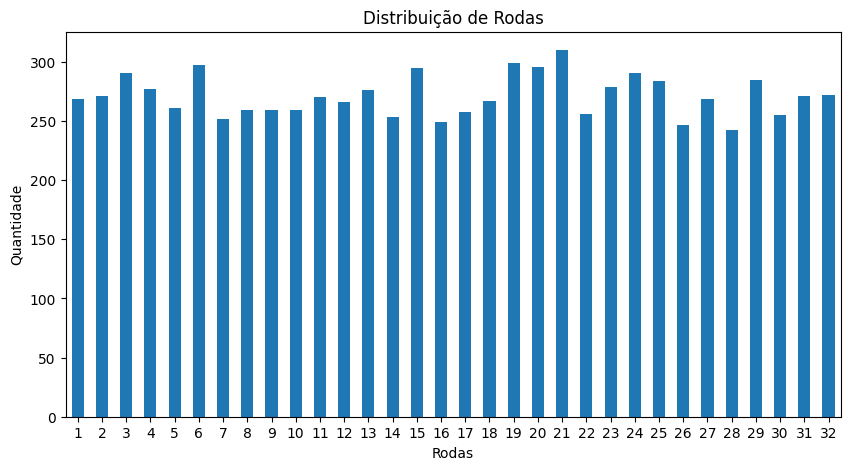

In [1577]:
import matplotlib.pyplot as plt

df["Rodas"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rodas")
plt.ylabel("Quantidade")
plt.title("Distribuição de Rodas")
plt.xticks(rotation=0)
plt.show()

In [1578]:
df['Rodas'].isna().sum()

0

In [1579]:
## Decidido por excluir a coluna "Rodas" devido a não conseguir entender o significado desse campo.
colunas_excluir = ["Rodas"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Cor

In [1580]:
df["Cor"].value_counts()

Cor
Preto       2354
Branco      2037
Prata       1648
Cinza       1089
Azul         640
Red          311
Verde        142
Marrom        87
Vermelho      85
Bege          64
Azul ceu      59
Dourado       57
Amarelo       55
Laranja       26
Roxo          19
Rosa          12
Name: count, dtype: int64

In [1581]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

mapeamento_cor = {
    "preto": "Preto",
    "branco": "Branco",
    "prata": "Prata",
    "cinza": "Cinza",
    "azul": "Azul",
    "azul ceu": "Azul",
    "red": "Vermelho",
    "vermelho": "Vermelho",
    "verde": "Verde",
    "marrom": "Marrom",
    "bege": "Bege",
    "amarelo": "Amarelo",
    "dourado": "Dourado",
    "laranja": "Laranja",
    "roxo": "Roxo",
    "rosa": "Rosa"
}

df["Cor"] = (
    df["Cor"]
    .apply(normalizar_texto)
    .map(mapeamento_cor)
    .fillna(df["Cor"])
)

In [1582]:
df["Cor"].value_counts()

Cor
Preto       2354
Branco      2037
Prata       1648
Cinza       1089
Azul         699
Vermelho     396
Verde        142
Marrom        87
Bege          64
Dourado       57
Amarelo       55
Laranja       26
Roxo          19
Rosa          12
Name: count, dtype: int64

In [1583]:
df['Cor'].isna().sum()

0

### Coluna Airbags

In [1584]:
df["Airbags"].value_counts()

Airbags
12    2673
4     2418
0     1071
8      733
6      620
2      521
10     395
5       47
16      45
7       40
1       38
9       27
3       23
11      20
14      10
15       4
Name: count, dtype: int64

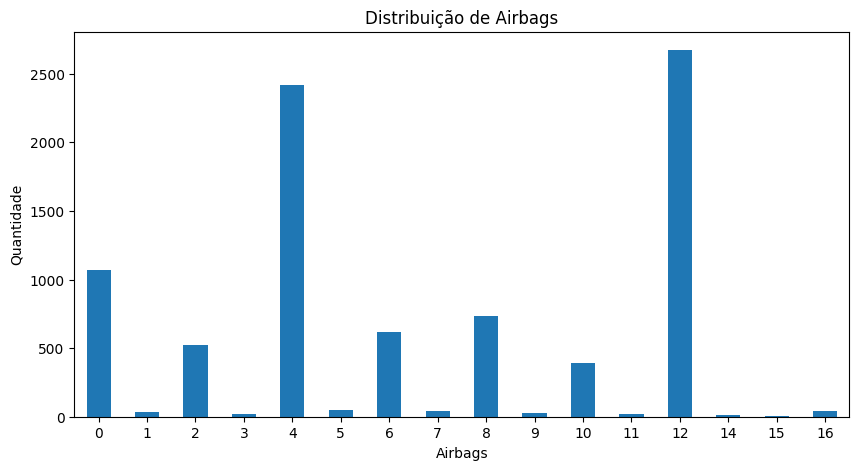

In [1585]:
df["Airbags"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Airbags")
plt.ylabel("Quantidade")
plt.title("Distribuição de Airbags")
plt.xticks(rotation=0)
plt.show()

In [1586]:
df['Airbags'].isna().sum()

0

### Coluna Preco

In [1587]:
df['Preco'].describe()

count      8261.000000
mean      17700.684421
std       26383.538613
min           1.000000
25%        4861.000000
50%       13172.000000
75%       22825.000000
max      886993.000000
Name: Preco, dtype: float64

In [1588]:
df["Preco"] = pd.to_numeric(df["Preco"], errors="coerce")
df = df.sort_values("Preco", ascending=True)
df.head(8000)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
7418,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.0,4,...,4,1.0,3,2022-03-01,Sim,FM,5,1816,Usado,Econômico
4524,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.0,4,...,8,3.0,3,2022-07-29,Não,AM,6,3838,Usado,Econômico
5588,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.0,4,...,0,3.0,5,2021-05-02,Sim,AM/FM,5,1003,Usado,Econômico
4701,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.0,4,...,6,3.0,5,2020-04-11,Não,AM/FM,10,7208,Usado,Econômico
715,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,NaN,6,...,2,3.0,4,2020-12-03,Sim,AM/FM,5,9266,Usado,Econômico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,0.0,BMW,X5,2013,SUV,Sim,Diesel,3.0,NaN,6,...,12,56450.0,3,2022-09-07,Não,FM,6,3069,Usado,Luxo
3214,0.0,PORSCHE,Cayenne,2011,SUV,Sim,Gasolina,3.5,171000.0,6,...,10,56450.0,3,2020-03-22,Não,AM/FM,7,4319,Usado,Luxo
7896,1053.0,MERCEDES-BENZ,ML 350,2014,SUV,Sim,Diesel,3.5,190000.0,6,...,0,56450.0,4,2020-07-02,Não,AM/FM,0,7069,Usado,Luxo
5608,1079.0,HONDA,Civic,2018,Sedan,Sim,Gasolina,2.0,26134.0,4,...,4,56509.0,2,2022-01-07,Sim,AM/FM,3,7158,Semi-novo,Luxo


In [1589]:
Q1 = df["Preco"].quantile(0.25)
Q3 = df["Preco"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_preco = df[(df["Preco"] < limite_inferior) | (df["Preco"] > limite_superior)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Q1: 4861.0
Q3: 22825.0
IQR: 17964.0
Limite inferior: -22085.0
Limite superior: 49771.0


In [1590]:
outliers_preco.head(100)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
8084,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,93555.0,4,...,4,49798.0,3,2020-01-11,Não,AM/FM,6,1059,Usado,Médio
427,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,93555.0,4,...,4,49798.0,2,2021-02-26,Não,FM,6,8004,Usado,Médio
2066,891.0,HYUNDAI,Santa FE,2016,SUV,Sim,Diesel,2.0,126465.0,4,...,4,49858.0,4,2020-05-15,Não,AM/FM,4,4812,Usado,Médio
266,1077.0,HYUNDAI,Tucson,2019,SUV,Sim,Diesel,2.0,48000.0,4,...,4,49858.0,5,2020-01-18,Não,FM,7,6728,Semi-novo,Médio
4973,891.0,HYUNDAI,Santa FE,2016,SUV,Sim,Diesel,2.0,126465.0,4,...,4,49858.0,1,2021-01-30,Sim,FM,3,3670,Usado,Médio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,1017.0,HYUNDAI,Sonata,2017,Sedan,Sim,Gasolina,2.0,37844.0,4,...,4,53282.0,4,2022-08-13,Sim,FM,6,8255,Usado,Luxo
1818,0.0,MERCEDES-BENZ,Viano,2013,Minivan,Sim,Diesel,2.2,250000.0,4,...,7,53314.0,5,2022-11-19,Não,FM,1,5973,Usado,Luxo
4493,1058.0,LEXUS,RX 450,2012,SUV,Sim,Híbrido,3.5,65000.0,6,...,8,53314.0,4,2020-03-26,Não,AM/FM,3,2405,Usado,Luxo
3746,1327.0,TOYOTA,Camry,2018,Sedan,Sim,Gasolina,2.5,NaN,6,...,8,53314.0,5,2021-04-23,Sim,AM,7,6060,Semi-novo,Luxo


In [1591]:
df = df[df["Preco"].notna()].copy()
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
7418,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.0,4,...,4,1.0,3,2022-03-01,Sim,FM,5,1816,Usado,Econômico
4524,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.0,4,...,8,3.0,3,2022-07-29,Não,AM,6,3838,Usado,Econômico
5588,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.0,4,...,0,3.0,5,2021-05-02,Sim,AM/FM,5,1003,Usado,Econômico
4701,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.0,4,...,6,3.0,5,2020-04-11,Não,AM/FM,10,7208,Usado,Econômico
715,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,NaN,6,...,2,3.0,4,2020-12-03,Sim,AM/FM,5,9266,Usado,Econômico


### Coluna Numero_proprietarios

In [1592]:
df["Numero_proprietarios"].value_counts()

Numero_proprietarios
2    1711
5    1653
1    1638
3    1635
4    1624
Name: count, dtype: int64

In [1593]:
df['Numero_proprietarios'].isna().sum()

0

### Coluna Data_ultima_lavagem

In [1594]:
df["Data_ultima_lavagem"].value_counts()

Data_ultima_lavagem
2020-11-05    19
2021-04-08    18
2020-05-23    17
2020-07-26    17
2020-04-06    16
              ..
2021-08-02     2
2021-02-21     2
2022-05-09     2
2020-02-12     1
2020-08-15     1
Name: count, Length: 1096, dtype: int64

In [1595]:
df["Data_ultima_lavagem"].astype(str).value_counts().head(30)

Data_ultima_lavagem
2020-11-05    19
2021-04-08    18
2020-05-23    17
2020-07-26    17
2020-04-06    16
2021-02-03    16
2021-04-03    16
2020-11-20    16
2022-03-10    15
2022-06-28    15
2022-02-01    15
2021-09-02    15
2020-03-09    15
2021-07-06    15
2022-05-17    14
2021-10-23    14
2021-12-08    14
2022-06-11    14
2022-08-10    14
2020-02-16    14
2020-10-22    14
2020-01-04    14
2021-01-22    14
2022-09-07    14
2022-11-20    14
2020-07-25    14
2020-06-17    14
2020-03-30    14
2022-08-17    14
2022-06-22    14
Name: count, dtype: int64

In [1596]:
df["Data_ultima_lavagem"] = pd.to_datetime(
    df["Data_ultima_lavagem"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [1597]:
# definir a data de referência
data_ref = pd.Timestamp("2023-01-01")

# calcular quantos dias se passaram
df["Dias_desde_ultima_lavagem"] = (data_ref - df["Data_ultima_lavagem"]).dt.days

df[["Data_ultima_lavagem", "Dias_desde_ultima_lavagem"]].head()

,Data_ultima_lavagem,Dias_desde_ultima_lavagem
7418,2022-03-01,306
4524,2022-07-29,156
5588,2021-05-02,609
4701,2020-04-11,995
715,2020-12-03,759


In [1598]:
df['Data_ultima_lavagem'].isna().sum()

0

### Coluna Adesivos_personalizados

In [1599]:
df["Adesivos_personalizados"].value_counts()

Adesivos_personalizados
Sim    4195
Não    4066
Name: count, dtype: int64

In [1600]:
df['Adesivos_personalizados'].isna().sum()

0

### Coluna Radio_AM_FM

In [1601]:
df["Radio_AM_FM"].value_counts()

Radio_AM_FM
FM       2809
AM/FM    2794
AM       2658
Name: count, dtype: int64

In [1602]:
df['Radio_AM_FM'].isna().sum()

0

### Coluna Historico_troca_oleo

In [1603]:
df["Historico_troca_oleo"].value_counts()

Historico_troca_oleo
9     800
8     769
6     764
4     764
0     755
1     754
10    737
5     732
7     732
3     732
2     722
Name: count, dtype: int64

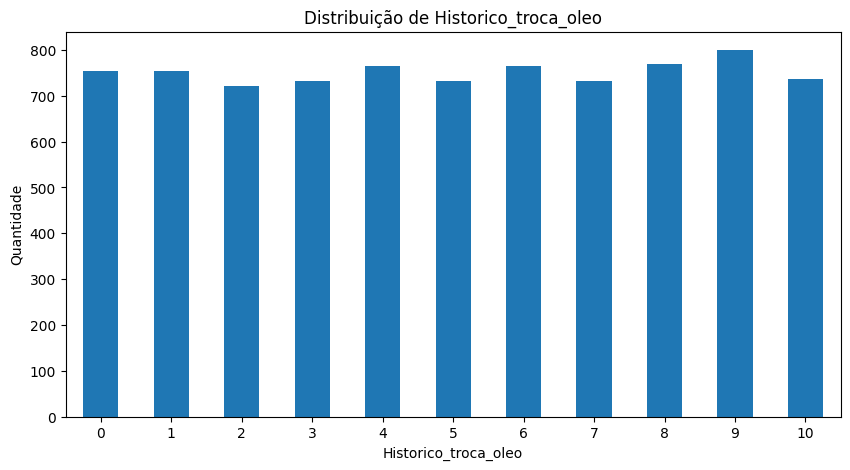

In [1604]:
df["Historico_troca_oleo"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Historico_troca_oleo")
plt.ylabel("Quantidade")
plt.title("Distribuição de Historico_troca_oleo")
plt.xticks(rotation=0)
plt.show()

In [1605]:
df['Historico_troca_oleo'].isna().sum()

0

### Coluna Codigo_concessionaria

In [1606]:
df["Codigo_concessionaria"].value_counts()

Codigo_concessionaria
6890    7
7213    6
2423    6
7539    6
7544    6
       ..
2547    1
4126    1
1743    1
7302    1
9941    1
Name: count, Length: 5399, dtype: int64

In [1607]:
colunas_excluir = ["Codigo_concessionaria"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Classificacao_Veiculo

In [1608]:
df["Classificacao_Veiculo"].value_counts()

Classificacao_Veiculo
Usado        7889
Semi-novo     372
Name: count, dtype: int64

In [1609]:
colunas_excluir = ["Classificacao_Veiculo"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Faixa_Preco

In [1610]:
df["Faixa_Preco"].value_counts()

Faixa_Preco
Econômico     5745
Médio         2107
Luxo           352
Muito Luxo      57
Name: count, dtype: int64

In [1611]:
colunas_excluir = ["Faixa_Preco"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Exportar para excel todos os possíveis valores das colunas

In [1612]:
import pandas as pd

lista = []

for col in df.columns:
    vc = df[col].value_counts(dropna=False).reset_index()
    vc.columns = ["valor", "quantidade"]
    vc.insert(0, "coluna", col)
    lista.append(vc)

resultado = pd.concat(lista, ignore_index=True)
resultado.to_excel("value_counts_todas_colunas.xlsx", index=False)

# Predição de valores ausentes na coluna km

In [1613]:
features_km = [
    'Débitos',
    'Fabricante',
    #'Modelo',
    'Ano',
    'Categoria',
    'Couro',
    'Combustivel',
    'Volume_motor',
    'Cilindros',
    'Tipo_cambio',
    'Tração',
    'Portas',
    'Cor',
    'Airbags',
    'Preco',
    'Numero_proprietarios',
    #'Data_ultima_lavagem',
    #'Adesivos_personalizados',
    #'Radio_AM_FM',
    'Historico_troca_oleo',
    'Dias_desde_ultima_lavagem'
]

In [1614]:
# 1. pegar apenas linhas com Km conhecido
train_km = df[df["Km"].notna()].copy()

# opcional: remover linhas com nulo nas features
train_km = train_km.dropna(subset=features_km)

X = train_km[features_km]
y = train_km["Km"]

# 2. separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. identificar colunas categóricas e numéricas
cat_km = X_train.select_dtypes(include="object").columns.tolist()
num_km = X_train.select_dtypes(exclude="object").columns.tolist()

# 4. pré-processamento
prep_km = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_km),
    ("num", "passthrough", num_km)
])

# 5. pipeline do modelo
model_km = Pipeline([
    ("prep", prep_km),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

# 6. treinar
model_km.fit(X_train, y_train)

# 7. prever no conjunto de teste
y_pred = model_km.predict(X_test)

# 8. métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 47869.99
RMSE: 85158.41
R²: 0.2394


In [1616]:
resultado_km = pd.DataFrame({
    "Km_real": y_test.values,
    "Km_predito": y_pred
}, index=y_test.index)

resultado_km = resultado_km.sort_values("Km_real", ascending=True)

resultado_km.head(20)

,Km_real,Km_predito
4887,10270.0,147129.615
4433,10610.0,19652.450
4094,11000.0,135492.385
5606,11000.0,124894.465
2749,11111.0,142358.205
433,11111.0,286417.445
507,11111.0,166121.640
578,11111.0,184940.305
6247,11111.0,291137.030
3471,11111.0,170211.355


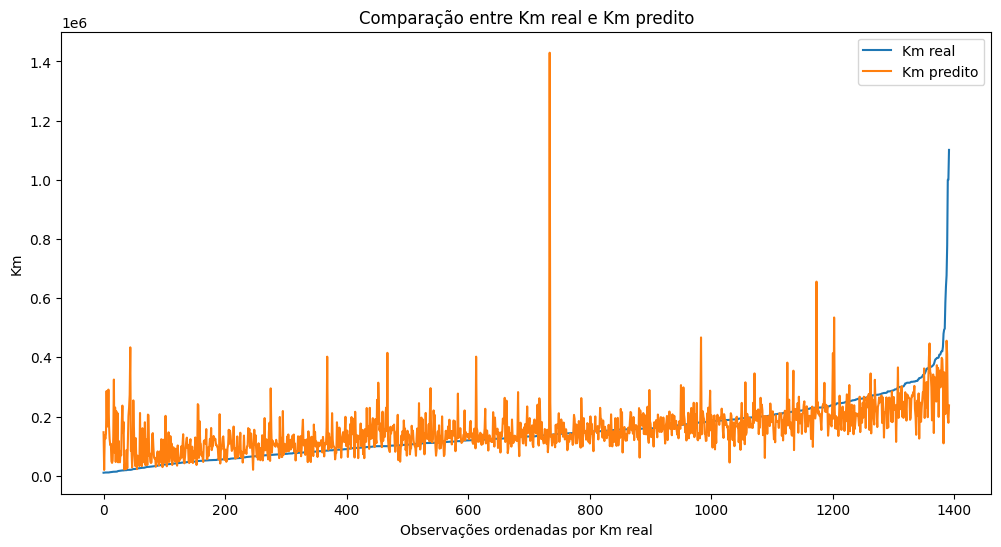

In [1617]:
import matplotlib.pyplot as plt

resultado_km = pd.DataFrame({
    "Km_real": y_test.values,
    "Km_predito": y_pred
}, index=y_test.index)

resultado_km = resultado_km.sort_values("Km_real", ascending=True).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(resultado_km["Km_real"].values, label="Km real")
plt.plot(resultado_km["Km_predito"].values, label="Km predito")
plt.xlabel("Observações ordenadas por Km real")
plt.ylabel("Km")
plt.title("Comparação entre Km real e Km predito")
plt.legend()
plt.show()

In [ ]:
# treinar com todos os registros que têm Km
train_km_full = df[df["Km"].notna()].copy()
train_km_full = train_km_full.dropna(subset=features_km)

pred_km = df[df["Km"].isna()].copy()
pred_km_valid = pred_km.dropna(subset=features_km)

X_train_full = train_km_full[features_km]
y_train_full = train_km_full["Km"]

cat_km = X_train_full.select_dtypes(include="object").columns.tolist()
num_km = X_train_full.select_dtypes(exclude="object").columns.tolist()

prep_km = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_km),
    ("num", "passthrough", num_km)
])

model_km_final = Pipeline([
    ("prep", prep_km),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

model_km_final.fit(X_train_full, y_train_full)

if len(pred_km_valid) > 0:
    df.loc[pred_km_valid.index, "Km"] = model_km_final.predict(pred_km_valid[features_km])

print("Faltantes restantes em Km:", df["Km"].isna().sum())

In [ ]:
df.to_csv('database/test_tratado.csv', index=False)
#df.to_csv('database/train_mod_tratado.csv', index=False)